In [4]:
                                       # PROJECT
# STEP 1:
# TITLE : AI-Powered Supermarket Sales Analytics and Quantity Prediction.
# NAME  : Anurag Das
# EMAIL : anuragd9692@gmail.com

## Project Overview :

#1.This project analyzes supermarket sales data to identify sales trends, customer behavior, product performance, and business patterns.
#2.The project also uses Machine Learning to predict product quantity and an anomaly detection technique to identify unusual transactions.

### Technologies Used :

#1.Python
#2.Pandas
#3.NumPy
#4.Matplotlib
#5.Seaborn
#6.SQL
#7.SQLite
#8.Scikit-learn
#9.Machine Learning

### Project Workflow :-

#1.Data Collection
#2.Data Cleaning
#3.Exploratory Data Analysis
#4.Data Visualization
#5.SQL Analysis
#6.Machine Learning Prediction
#7.Model Evaluation
#8.Anomaly Detection
#9.Business Insights

In [5]:
#   STEP 2 : (Installing pip)
!pip install pandas numpy matplotlib seaborn scikit-learn -q

In [6]:
# STEP 3 : Importing Libararies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import Warnings:
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# STEP 4 : loading the Dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/supermarket_sales.csv"

try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully from online source.")
except:
    print("Online dataset could not be loaded.")

Dataset loaded successfully from online source.


In [8]:
# STEP 5 : Checking the Rows & Columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 17


In [9]:
# STEP 6 : Checking head
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [10]:
# STEP 7 : Understanding the dataset
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']


In [11]:
# STEP 8 : Checking info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [12]:
# STEP 9 : Check Describe
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [13]:
# STEP 10 : Checking Missing & Duplicate value's
print("Missing Values:")
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

Missing Values:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64
Duplicate Rows: 0


In [14]:
# STEP 11 : Cleaning the Data
df = df.drop_duplicates()

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Time"] = pd.to_datetime(
    df["Time"],
    format="%H:%M",
    errors="coerce"
)

print("Data cleaning completed.")

Data cleaning completed.


In [15]:
# STEP 12 : Featiure Enginerring (Checks the Date & Time)
df["Hour"] = df["Time"].dt.hour
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Day_Name"] = df["Date"].dt.day_name()

print(df[["Date", "Time", "Hour", "Day", "Month", "Day_Name"]].head())

        Date                Time  Hour  Day  Month  Day_Name
0 2019-01-05 1900-01-01 13:08:00    13    5      1  Saturday
1 2019-03-08 1900-01-01 10:29:00    10    8      3    Friday
2 2019-03-03 1900-01-01 13:23:00    13    3      3    Sunday
3 2019-01-27 1900-01-01 20:33:00    20   27      1    Sunday
4 2019-02-08 1900-01-01 10:37:00    10    8      2    Friday


In [16]:
# STEP 13 : Sales Analysis
total_sales = df["Total"].sum()
average_sales = df["Total"].mean()
total_quantity = df["Quantity"].sum()

print("Total Sales:", round(total_sales, 2))
print("Average Transaction Sales:", round(average_sales, 2))
print("Total Quantity Sold:", total_quantity)

Total Sales: 322966.75
Average Transaction Sales: 322.97
Total Quantity Sold: 5510


In [17]:
# STEP 14 : Sales by Branch
branch_sales = df.groupby("Branch")["Total"].sum().sort_values(ascending=False)

print(branch_sales)

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64


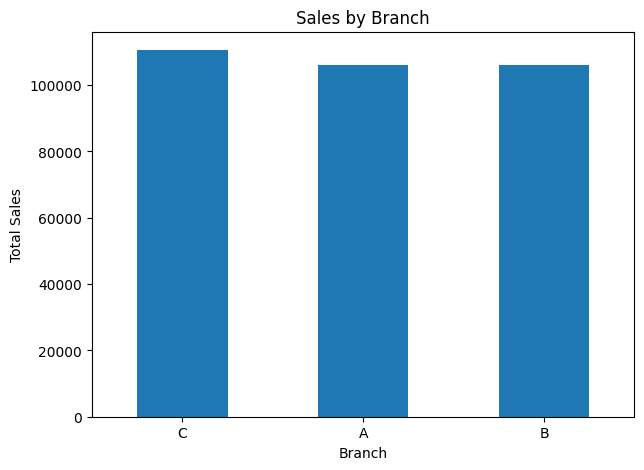

In [19]:
# Visualization : (Sales by Branch)
branch_sales.plot(kind="bar", figsize=(7,5))

plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [20]:
# STEP 15 : Sales by product line
product_sales = (
    df.groupby("Product line")["Total"]
    .sum()
    .sort_values(ascending=False)
)

print(product_sales)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64


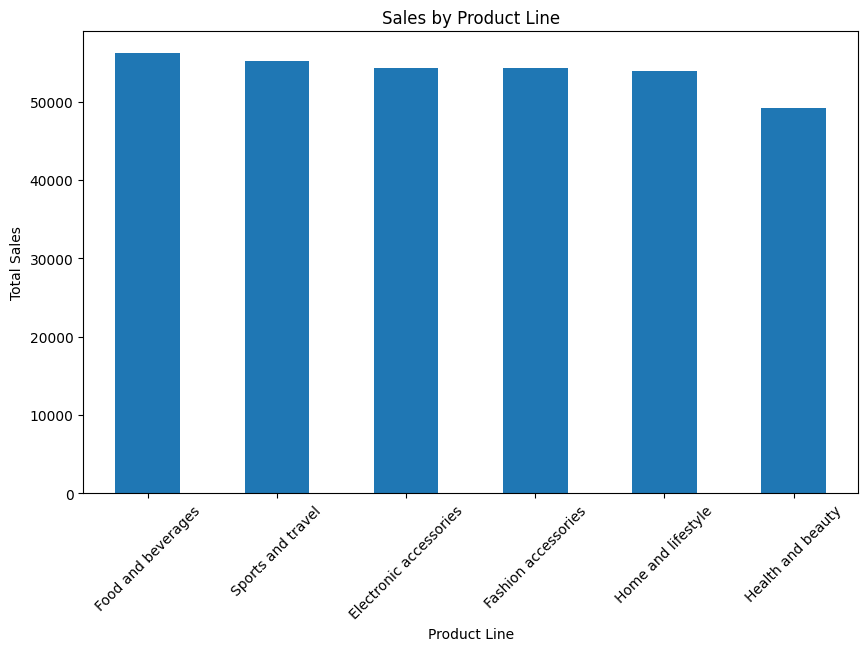

In [21]:
# Visualization : (Sales by product Line)
plt.figure(figsize=(10,6))

product_sales.plot(kind="bar")

plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [24]:
# STEP 16 : Quantity Sold by Product Line
quantity_product = (
    df.groupby("Product line")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(quantity_product)

Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64


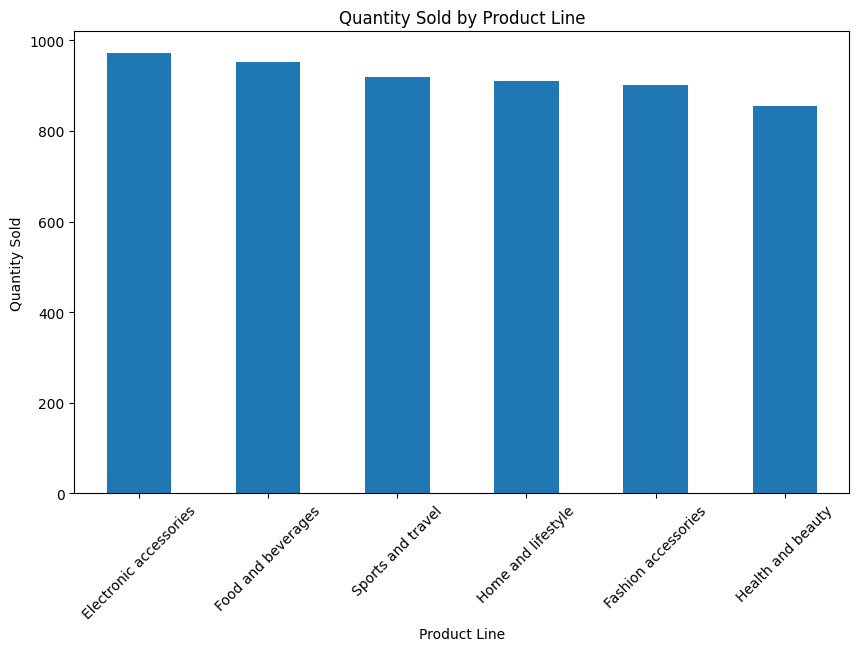

In [25]:
# Visualization : (Quantity Sold by Product Line)
plt.figure(figsize=(10,6))

quantity_product.plot(kind="bar")

plt.title("Quantity Sold by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [26]:
# STEP 17 : Customer Analysis:
customer_sales = df.groupby("Customer type")["Total"].sum()

print(customer_sales)

Customer type
Member    164223.444
Normal    158743.305
Name: Total, dtype: float64


In [27]:
gender_sales = df.groupby("Gender")["Total"].sum()

print(gender_sales)

Gender
Female    167882.925
Male      155083.824
Name: Total, dtype: float64


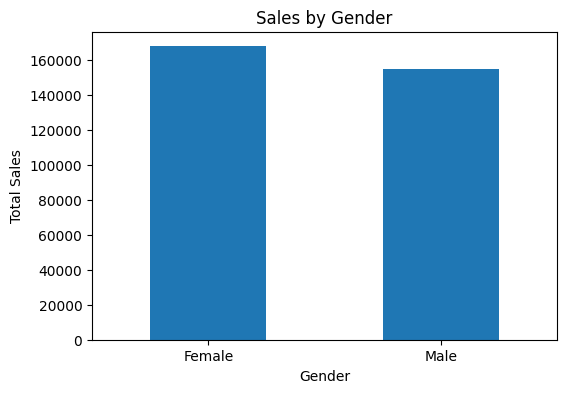

In [28]:
# Visulaization (Sales by Gender)
gender_sales.plot(kind="bar", figsize=(6,4))

plt.title("Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [29]:
# STEP 18 : payment Analysis
payment_count = df["Payment"].value_counts()

print(payment_count)

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


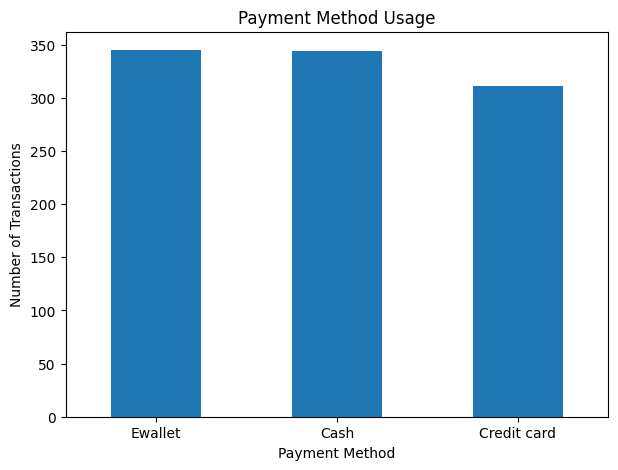

In [31]:
# Visualization : (Payment Method Usage)
payment_count.plot(kind="bar", figsize=(7,5))

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

In [32]:
# STEP 19 : Sales by Day
day_sales = (
    df.groupby("Day_Name")["Total"]
    .sum()
)

print(day_sales)

Day_Name
Friday       43926.3405
Monday       37899.0780
Saturday     56120.8095
Sunday       44457.8925
Thursday     45349.2480
Tuesday      51482.2455
Wednesday    43731.1350
Name: Total, dtype: float64


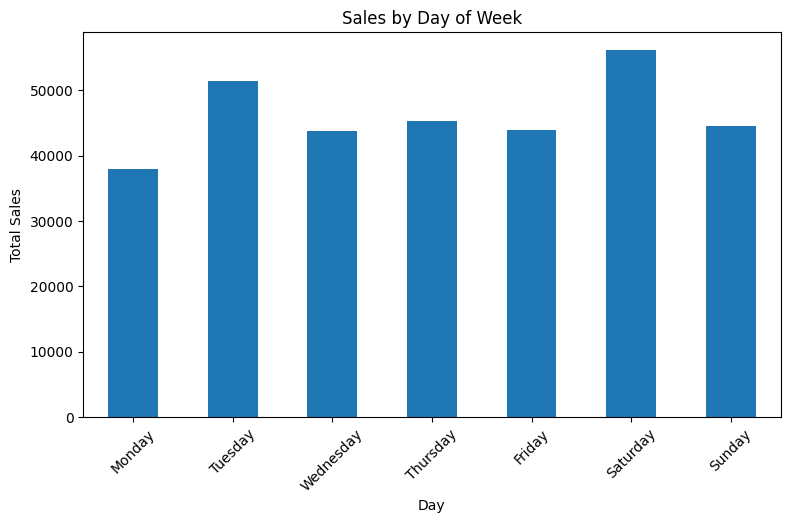

In [34]:
# Visualization : (Sales by Day Week)
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = day_sales.reindex(day_order)

day_sales.plot(kind="bar", figsize=(9,5))

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [35]:
# STEP 20 : Sales by Hour
hour_sales = df.groupby("Hour")["Total"].sum()

print(hour_sales)

Hour
10    31421.4810
11    30377.3295
12    26065.8825
13    34723.2270
14    30828.3990
15    31179.5085
16    25226.3235
17    24445.2180
18    26030.3400
19    39699.5130
20    22969.5270
Name: Total, dtype: float64


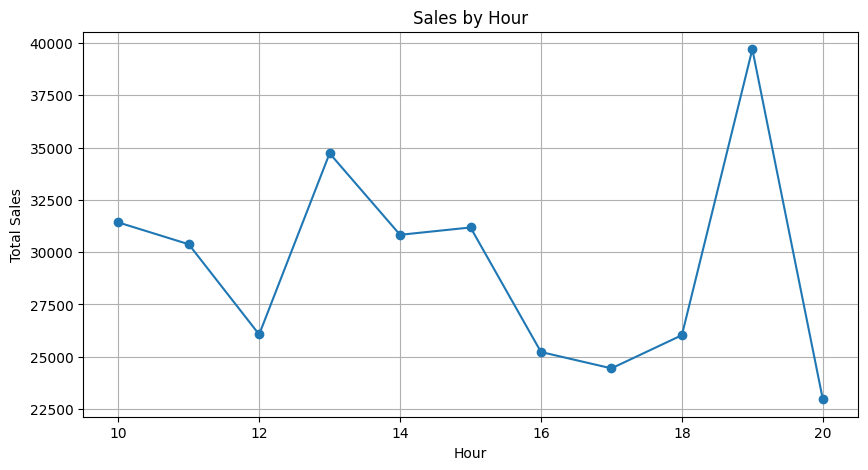

In [37]:
# Visualization : (Sales by Hour)
plt.figure(figsize=(10,5))

hour_sales.plot(kind="line", marker="o")

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Total Sales")
plt.grid()
plt.show()

In [38]:
# STEP 21 : Rating Analysis
average_rating = df["Rating"].mean()

print("Average Customer Rating:", round(average_rating, 2))

Average Customer Rating: 6.97


In [39]:
rating_product = (
    df.groupby("Product line")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print(rating_product)

Product line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: Rating, dtype: float64


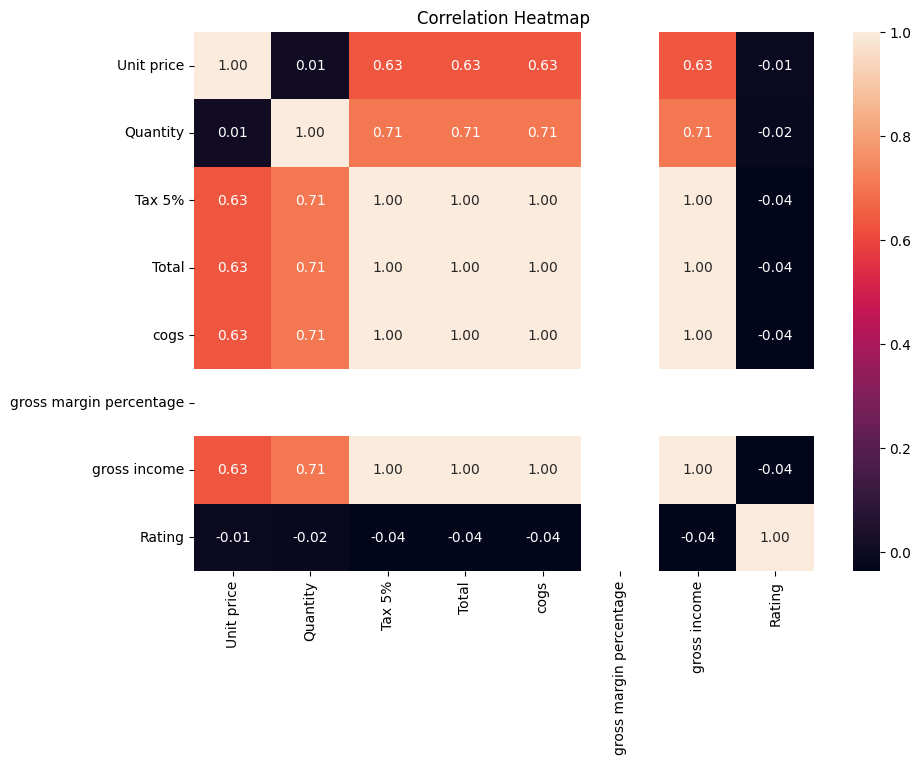

In [42]:
# Visualization : (Correlation Heatmap)
numeric_columns = [
    "Unit price",
    "Quantity",
    "Tax 5%",
    "Total",
    "cogs",
    "gross margin percentage",
    "gross income",
    "Rating"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [43]:
# STEP 22 : SQL Analysis
connection = sqlite3.connect("supermarket.db")

df.to_sql(
    "sales",
    connection,
    if_exists="replace",
    index=False
)

print("Data loaded into SQLite database.")

Data loaded into SQLite database.


In [44]:
# STEP 23 : Total Sales
query = """
SELECT SUM(Total) AS Total_Sales
FROM sales;
"""

result = pd.read_sql_query(query, connection)

result

,Total_Sales
0,322966.749


In [45]:
# STEP 24 : Sales by branch
query = """
SELECT
    Branch,
    SUM(Total) AS Total_Sales
FROM sales
GROUP BY Branch
ORDER BY Total_Sales DESC;
"""

branch_sql = pd.read_sql_query(query, connection)

branch_sql

,Branch,Total_Sales
0,C,110568.7065
1,A,106200.3705
2,B,106197.6720


In [46]:
# STEP 24 : Sales by Product Line
query = """
SELECT
    "Product line",
    SUM(Total) AS Total_Sales
FROM sales
GROUP BY "Product line"
ORDER BY Total_Sales DESC;
"""

product_sql = pd.read_sql_query(query, connection)

product_sql

,Product line,Total_Sales
0,Food and beverages,56144.8440
1,Sports and travel,55122.8265
2,Electronic accessories,54337.5315
3,Fashion accessories,54305.8950
4,Home and lifestyle,53861.9130
5,Health and beauty,49193.7390


In [47]:
# STEP 25 : Average Rating by product
query = """
SELECT
    "Product line",
    ROUND(AVG(Rating), 2) AS Average_Rating
FROM sales
GROUP BY "Product line"
ORDER BY Average_Rating DESC;
"""

rating_sql = pd.read_sql_query(query, connection)

rating_sql

,Product line,Average_Rating
0,Food and beverages,7.11
1,Fashion accessories,7.03
2,Health and beauty,7.00
3,Sports and travel,6.92
4,Electronic accessories,6.92
5,Home and lifestyle,6.84


In [48]:
# STEP 26 : Customer Type
query = """
SELECT
    "Customer type",
    COUNT(*) AS Transactions,
    ROUND(SUM(Total), 2) AS Total_Sales
FROM sales
GROUP BY "Customer type"
ORDER BY Total_Sales DESC;
"""

customer_sql = pd.read_sql_query(query, connection)

customer_sql

,Customer type,Transactions,Total_Sales
0,Member,501,164223.44
1,Normal,499,158743.30


In [49]:
# STEP 27 : Preparing ML Data
ml_df = df.copy()

ml_df["Hour"] = ml_df["Time"].dt.hour
ml_df["Day"] = ml_df["Date"].dt.day
ml_df["Month"] = ml_df["Date"].dt.month

features = [
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Product line",
    "Unit price",
    "Hour",
    "Day",
    "Month",
    "Payment",
    "Rating"
]

target = "Quantity"

X = ml_df[features]
y = ml_df[target]

print("Features:")
print(features)

print("\nTarget:")
print(target)

Features:
['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Hour', 'Day', 'Month', 'Payment', 'Rating']

Target:
Quantity


In [50]:
# STEP 28 : Train & Testing Spilt
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 800
Testing records: 200


In [51]:
# STEP 29 : preparing Categorical Features
categorical_features = [
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Product line",
    "Payment"
]

numeric_features = [
    "Unit price",
    "Hour",
    "Day",
    "Month",
    "Rating"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [52]:
# STEP 30 : Created Random Forest Model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Random Forest model created.")

Random Forest model created.


In [53]:
# STEP 31 : Training a model
pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [54]:
# STEP 32 : Making a Predictions
y_pred = pipeline.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[4.805 4.785 5.32  6.7   6.19  6.055 5.35  4.285 5.965 5.755]


In [55]:
# STEP 33 : Evaluated a Model
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

Model Evaluation
----------------
MAE : 2.435
RMSE: 2.89
R²  : -0.071


In [56]:
# STEP 34 : Actual model vs Predicted model
comparison = pd.DataFrame({
    "Actual Quantity": y_test.values,
    "Predicted Quantity": np.round(y_pred, 2)
})

comparison.head(15)

,Actual Quantity,Predicted Quantity
0,6,4.80
1,10,4.78
2,7,5.32
3,3,6.70
4,2,6.19
5,10,6.06
6,2,5.35
7,7,4.28
8,9,5.96
9,5,5.76


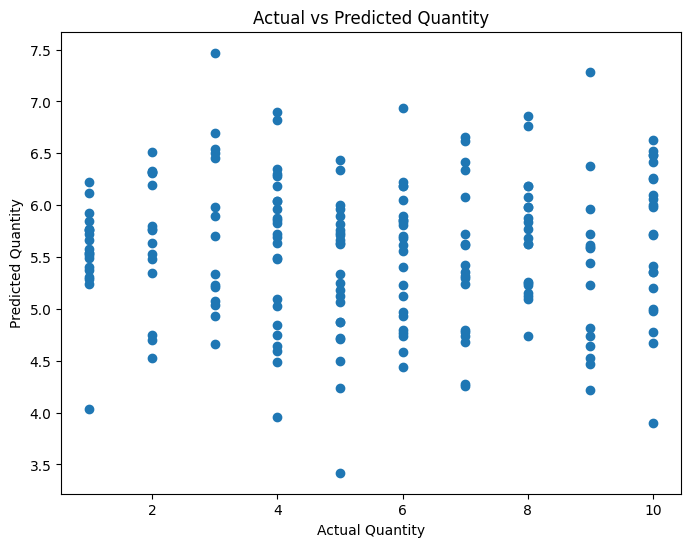

In [58]:
# Visualization : (Actual model vs Predicted model)
plt.figure(figsize=(8,6))

plt.scatter(
    comparison["Actual Quantity"],
    comparison["Predicted Quantity"]
)

plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Actual vs Predicted Quantity")

plt.show()

In [59]:
# STEP 35 : Feature Importance
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
19,numeric__Unit price,0.227813
23,numeric__Rating,0.188145
21,numeric__Day,0.151301
20,numeric__Hour,0.109765
22,numeric__Month,0.039726
11,categorical__Product line_Fashion accessories,0.024409
17,categorical__Payment_Credit card,0.020170
12,categorical__Product line_Food and beverages,0.019807
16,categorical__Payment_Cash,0.019382
18,categorical__Payment_Ewallet,0.018442


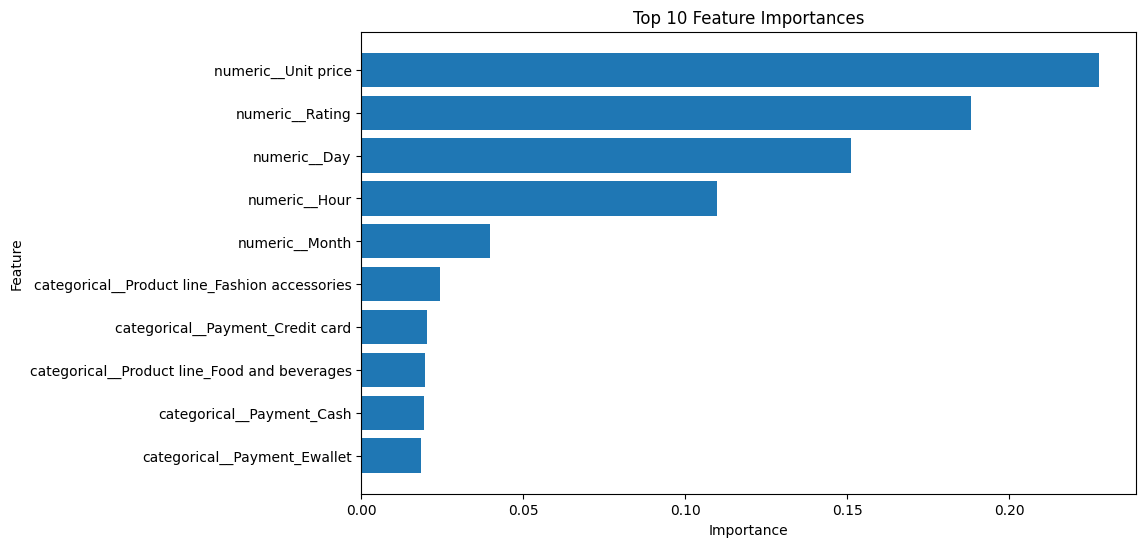

In [61]:
# Visualization-(Top 10 Features)
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [62]:
# STEP 36 : Anomaly Detection
anomaly_data = df[
    [
        "Unit price",
        "Quantity",
        "Total",
        "Rating"
    ]
].copy()

anomaly_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_model.fit(anomaly_data)

df["Anomaly"] = anomaly_model.predict(anomaly_data)

print(df["Anomaly"].value_counts())

Anomaly
 1    950
-1     50
Name: count, dtype: int64


In [64]:
# STEP 37 : Showing Anomalies
anomalies = df[df["Anomaly"] == -1]

print("Potential anomalies:", len(anomalies))

anomalies[
    [
        "Invoice ID",
        "Branch",
        "Product line",
        "Unit price",
        "Quantity",
        "Total",
        "Rating"
    ]
].head(20)

Potential anomalies: 50


,Invoice ID,Branch,Product line,Unit price,Quantity,Total,Rating
67,109-28-2512,B,Fashion accessories,97.61,6,614.9430,9.9
70,393-65-2792,C,Food and beverages,89.48,10,939.5400,9.6
96,766-85-7061,B,Health and beauty,87.87,10,922.6350,5.1
105,704-48-3927,A,Electronic accessories,88.67,10,931.0350,7.3
109,861-77-0145,C,Electronic accessories,81.97,10,860.6850,9.2
120,638-60-7125,A,Electronic accessories,99.56,8,836.3040,5.2
122,219-22-9386,B,Sports and travel,99.96,9,944.6220,4.2
140,731-81-9469,C,Sports and travel,89.80,10,942.9000,5.4
141,280-17-4359,C,Health and beauty,90.50,10,950.2500,8.1
158,743-04-1105,B,Health and beauty,97.22,9,918.7290,6.0


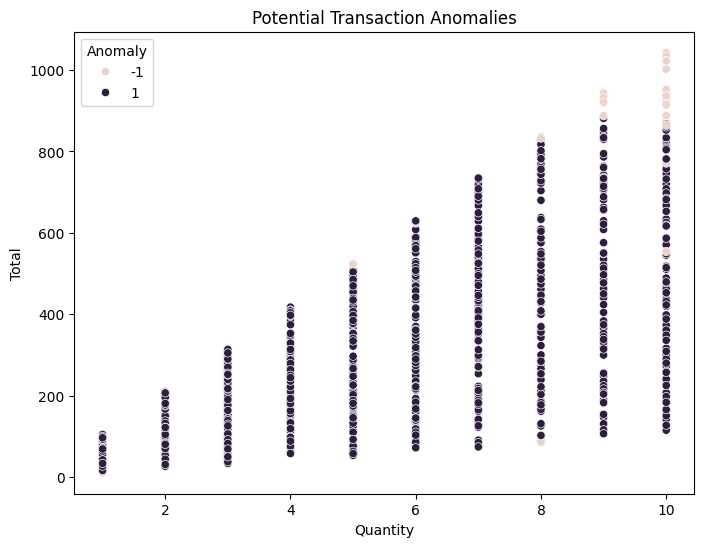

In [65]:
# STEP 38 : Anomaly visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total",
    hue="Anomaly"
)

plt.title("Potential Transaction Anomalies")
plt.show()

In [66]:
# STEP 39 : Final Business Findings
best_branch = branch_sales.idxmax()
best_product = product_sales.idxmax()
best_day = day_sales.idxmax()
best_payment = payment_count.idxmax()

print("FINAL BUSINESS FINDINGS")
print("=======================")

print("Highest Sales Branch:", best_branch)
print("Highest Sales Product Line:", best_product)
print("Highest Sales Day:", best_day)
print("Most Used Payment Method:", best_payment)

print("Average Customer Rating:", round(average_rating, 2))

print("Total Sales:", round(total_sales, 2))
print("Total Quantity Sold:", total_quantity)

print("Potential Anomalies:", len(anomalies))

print("\nMODEL PERFORMANCE")
print("-----------------")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

FINAL BUSINESS FINDINGS
Highest Sales Branch: C
Highest Sales Product Line: Food and beverages
Highest Sales Day: Saturday
Most Used Payment Method: Ewallet
Average Customer Rating: 6.97
Total Sales: 322966.75
Total Quantity Sold: 5510
Potential Anomalies: 50

MODEL PERFORMANCE
-----------------
MAE : 2.435
RMSE: 2.89
R²  : -0.071


In [68]:
# STEP 40 : Saving Important Results
df.to_csv(
    "cleaned_supermarket_sales.csv",
    index=False
)

branch_sales.to_csv(
    "branch_sales.csv"
)

product_sales.to_csv(
    "product_sales.csv"
)

comparison.to_csv(
    "actual_vs_predicted.csv",
    index=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

anomalies.to_csv(
    "anomalies.csv",
    index=False
)

print("All important output files saved.")

All important output files saved.


In [69]:
# STEP 41 : Saves Model Metrics
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

metrics.to_csv(
    "model_metrics.csv",
    index=False
)

metrics

,Metric,Value
0,MAE,2.434700
1,RMSE,2.889508
2,R2,-0.070696


In [70]:
# STEP 42 : Downloading Results
from google.colab import files

files.download("cleaned_supermarket_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
# STEP 43 : Dowloading All model file's
files.download("branch_sales.csv")
files.download("product_sales.csv")
files.download("model_metrics.csv")
files.download("feature_importance.csv")
files.download("anomalies.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
# Thank You!